In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
import json
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid

In [2]:
from utils import DataHandler
from ESN import ClassicalRC
from qiskit.circuit.library import ZZFeatureMap
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC, GBPermanents
from circuits import CPCircuit

In [3]:
from joblib import Parallel, delayed
import itertools

# Define your tau and ph lists
taus = [12, 17, 30, 50]
phs = list(range(1, 20, 1))  # or any range of prediction horizons

# Grid of (tau, ph) combinations
param_grid = list(itertools.product(taus, phs))

# Global constants
n_samples = 10000
window_size = 12
tr = 0.75
train_size = int(n_samples*tr) 

In [10]:
param_grid = {
    'reservoir_size': [150, 300],
    'spectral_radius': [0.2, 0.3, 0.4],
    'sparsity': [0.3],
    'noise': [0.0001],
    'ridge_alpha': [0.001]
}

# Storage dictionaries
Best_Params = {}
MSEs = {}

# Iterate over different tau values
for tau in tqdm(taus, desc="Running HPO over all taus"):

    # Load dataset
    X, Y = DataHandler().load_dataset(
        'mackey_glass',
        n_samples=n_samples,
        tau=tau,
        window_size=window_size,
        prediction_horizon=20,
        plot=False
    )
    
    # Split into train/test
    X_train_, X_test_ = X[:train_size], X[train_size:]
    y_train, y_test = Y[:train_size], Y[train_size:]

    # Normalize inputs
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_)
    X_test = scaler.transform(X_test_)

    # HPO loop
    best_score = float('inf')
    best_params = None

    for params in ParameterGrid(param_grid):
        CRM = ClassicalRC(
            input_size=window_size,
            reservoir_size=params['reservoir_size'],
            spectral_radius=params['spectral_radius'],
            sparsity=params['sparsity'],
            noise=params['noise'],
            use_reservoir=True
        )

        CRM.train(X_train, y_train, model_type="ridge", alpha=params['ridge_alpha'])
        y_pred = CRM.predict(X_test)
        score = mean_squared_error(y_test, y_pred)

        if score < best_score:
            best_score = score
            best_params = params

    # Save best results for current tau
    Best_Params[str(tau)] = best_params
    MSEs[str(tau)] = best_score

    print(f"Tau={tau} → Best MSE: {best_score:.2e}, Best Params: {best_params}")

# Save results to file
results = {
    "best_params_per_tau": Best_Params,
    "mse_per_tau": MSEs
}

with open("best_params_all_taus.json", "w") as f:
    json.dump(results, f, indent=4)

print("\n✅ Hyperparameter optimization complete. Results saved to 'best_params_all_taus.json'.")


Running HPO over all taus:  25%|████▌             | 1/4 [00:02<00:06,  2.20s/it]

Tau=12 → Best MSE: 1.56e-05, Best Params: {'noise': 0.0001, 'reservoir_size': 150, 'ridge_alpha': 0.001, 'sparsity': 0.3, 'spectral_radius': 0.2}


Running HPO over all taus:  50%|█████████         | 2/4 [00:04<00:04,  2.02s/it]

Tau=17 → Best MSE: 1.19e-03, Best Params: {'noise': 0.0001, 'reservoir_size': 300, 'ridge_alpha': 0.001, 'sparsity': 0.3, 'spectral_radius': 0.4}


Running HPO over all taus:  75%|█████████████▌    | 3/4 [00:06<00:02,  2.09s/it]

Tau=30 → Best MSE: 3.01e-02, Best Params: {'noise': 0.0001, 'reservoir_size': 300, 'ridge_alpha': 0.001, 'sparsity': 0.3, 'spectral_radius': 0.4}


Running HPO over all taus: 100%|██████████████████| 4/4 [00:08<00:00,  2.08s/it]

Tau=50 → Best MSE: 8.26e-02, Best Params: {'noise': 0.0001, 'reservoir_size': 150, 'ridge_alpha': 0.001, 'sparsity': 0.3, 'spectral_radius': 0.2}

✅ Hyperparameter optimization complete. Results saved to 'best_params_all_taus.json'.


In [4]:
def run_CRC(tau, ph, seed=42):
    """
    Runs both CPMap and ZZFeatureMap reservoirs on the same dataset and returns their results.

    Returns:
        List[dict]: Two result dictionaries, one for each feature map.
    """
    np.random.seed(seed + tau + ph)

    # Load data once
    X, Y = DataHandler().load_dataset(
        'mackey_glass',
        n_samples=n_samples,
        tau=tau,
        window_size=window_size,
        prediction_horizon=ph,
        plot=False
    )

    X_train_, X_test_ = X[:train_size], X[train_size:]
    y_train, y_test = Y[:train_size], Y[train_size:]

    # Normalize once
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_)
    X_test = scaler.transform(X_test_)

    dim = len(X_train[0])  # Should equal window_size

    results = []

    ### 🔷 CPMap
    CRM = ClassicalRC(
            input_size=window_size,
            reservoir_size=150,
            spectral_radius=0.2,
            sparsity=0.3,
            noise=0.0001,
            use_reservoir=True
        )

    CRM.train(X_train, y_train, model_type="ridge", alpha=0.001)
    y_pred = CRM.predict(X_test)
    score = mean_squared_error(y_test, y_pred)

    results.append({
        "tau": tau,
        "ph": ph,
        "rmse": score,
        "y_test": y_test.tolist(),
        "y_pred": y_pred.tolist(),
        "RC": "Classical"
    })
    return results


In [5]:
param_grid = list(itertools.product(taus, phs))

all_results = Parallel(n_jobs=-1)(
    delayed(run_CRC)(tau, ph) for tau, ph in tqdm(param_grid)
)
# Flatten nested list
flat_results = [item for sublist in all_results for item in sublist]


00%|███████████████████████████████████████████| 76/76 [00:09<00:00,  8.28it/s]

In [6]:
import pickle
with open("results_CRC.pkl", "wb") as f:
    pickle.dump(flat_results, f)

In [7]:
import pandas as pd

df = pd.DataFrame(flat_results)

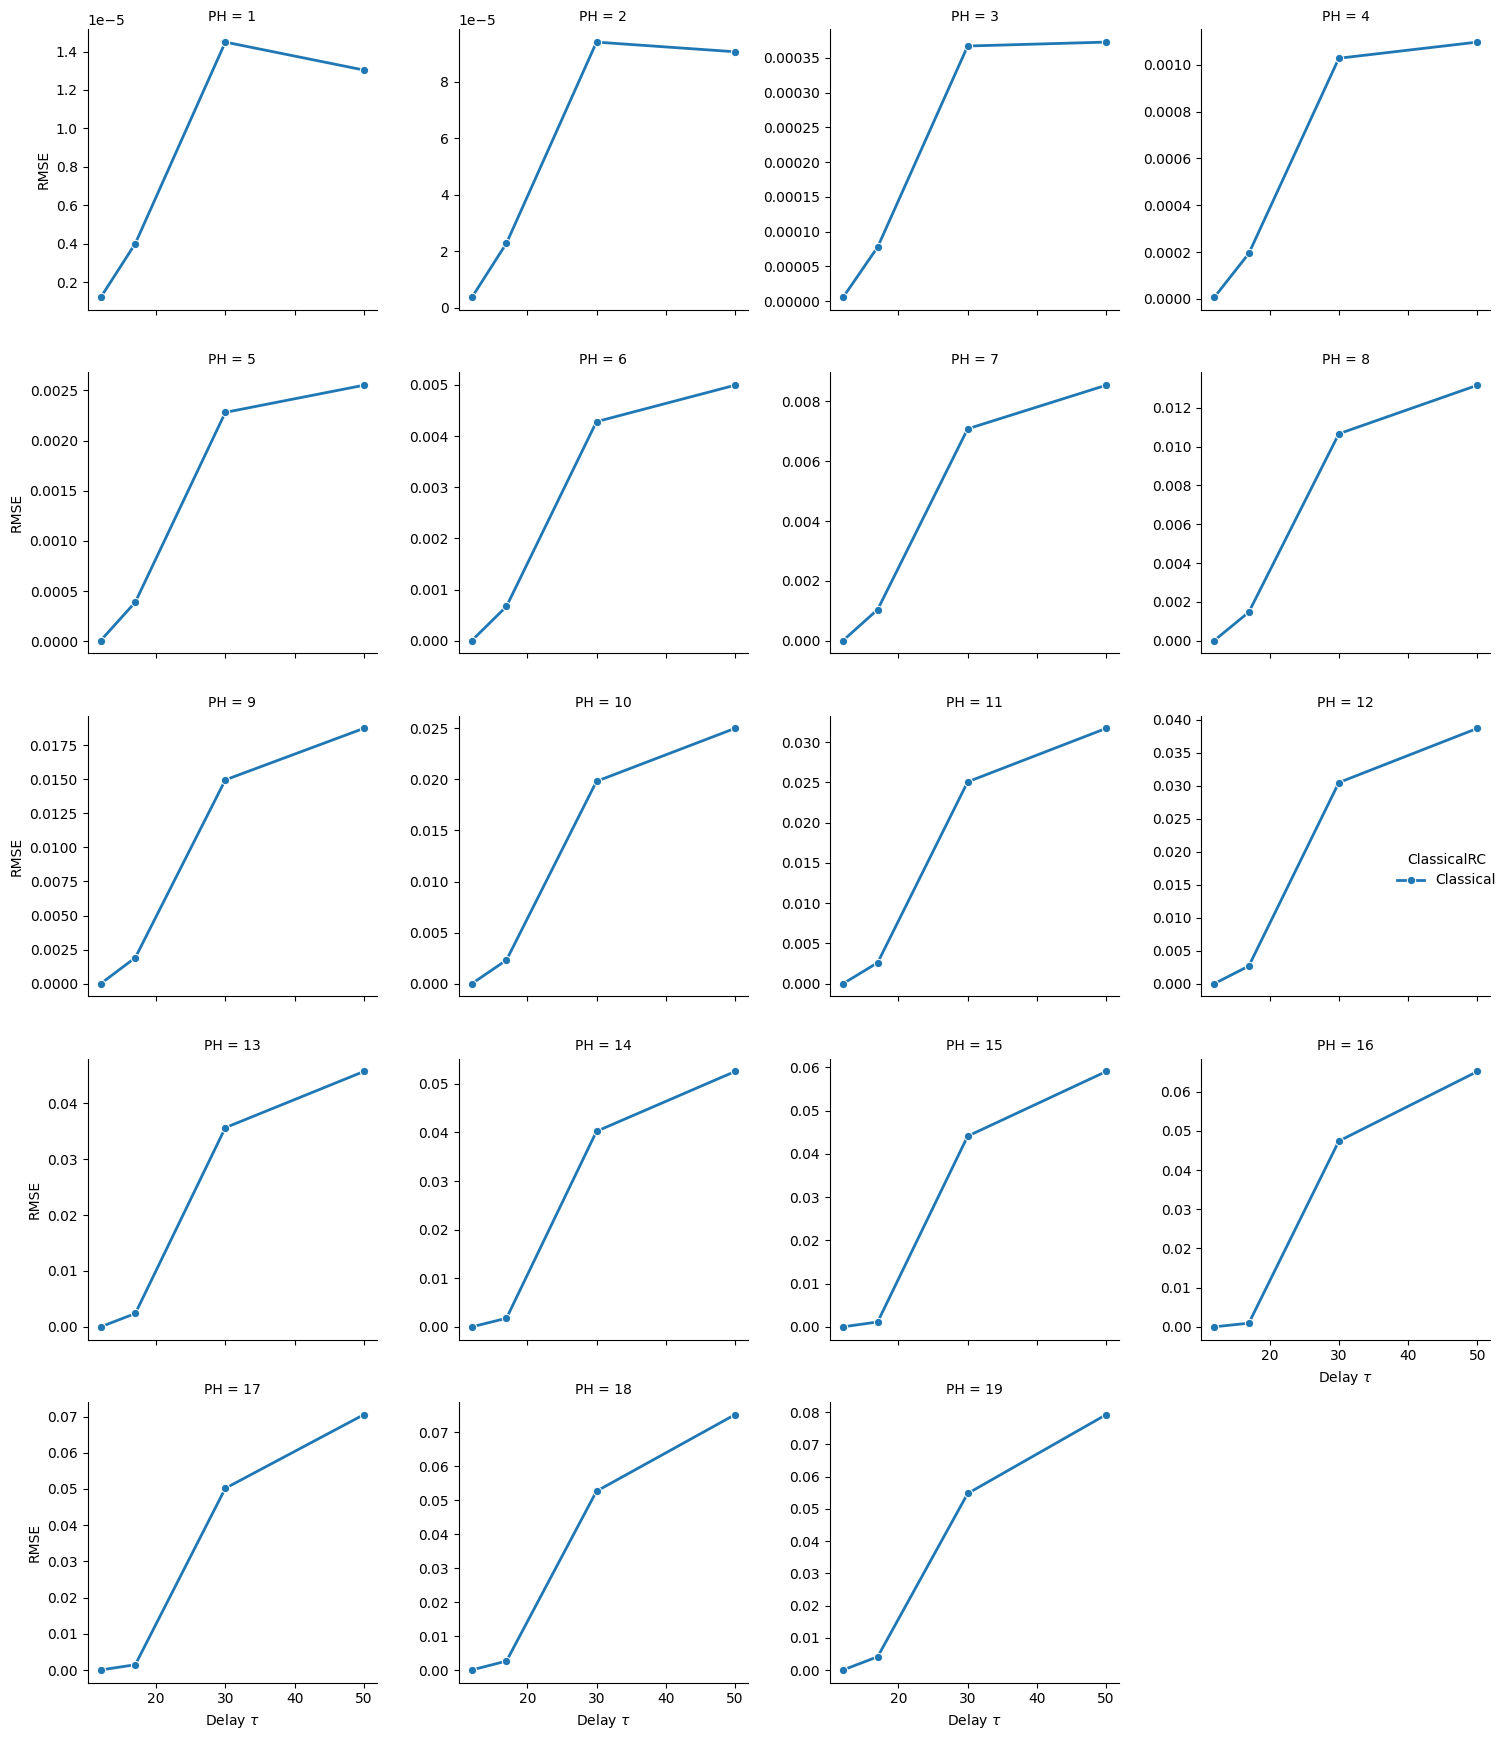

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure 'tau', 'ph', and 'rmse' are numeric
df['tau'] = df['tau'].astype(int)
df['ph'] = df['ph'].astype(int)

# Create FacetGrid: one subplot per ph
g = sns.FacetGrid(df, col="ph", col_wrap=4, height=3.5, sharey=False)
g.map_dataframe(sns.lineplot, x="tau", y="rmse", hue="RC", marker="o", linewidth=2)

# Improve layout and labels
g.set_axis_labels(r"Delay $\tau$", "RMSE")
g.add_legend(title="ClassicalRC")
g.set_titles("PH = {col_name}")
plt.tight_layout()

# Save
# g.savefig("figures/crc_rmse_vs_tau_multiple_phs.pdf")
# g.savefig("figures/crc_rmse_vs_tau_multiple_phs.png", dpi=300)
plt.show()


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

ph_values = phs

df_plot = df.copy()
df_plot['tau'] = df_plot['tau'].astype(int)
df_plot['ph'] = df_plot['ph'].astype(int)
df_plot = df_plot[df_plot['ph'].isin(ph_values)]

# Optional: sanity check
print("PHs in DataFrame:", sorted(df_plot['ph'].unique()))  # should print [2, 4, ..., 18]

PHs in DataFrame: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


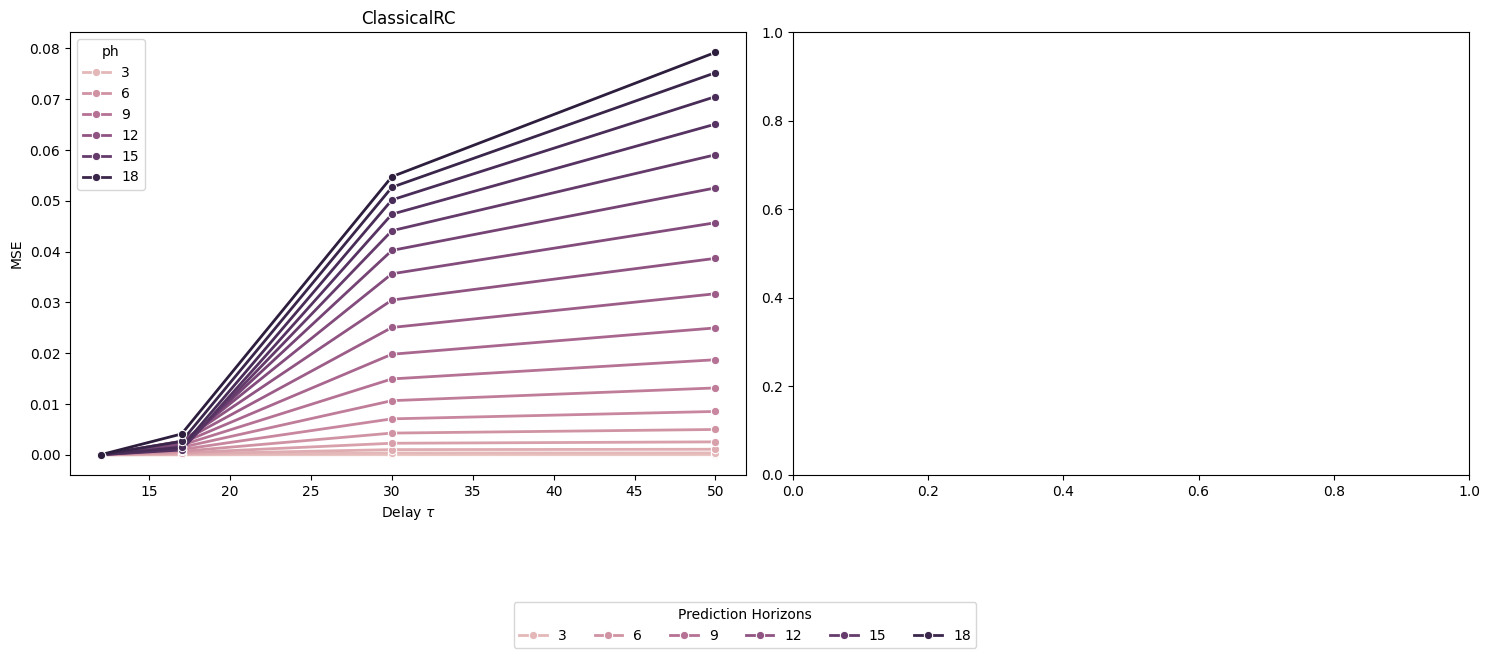

In [14]:
# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot CPMap
sns.lineplot(
    data=df_plot[df_plot['RC'] == 'Classical'],
    x='tau',
    y='rmse',
    hue='ph',
    hue_order=ph_values,
    marker='o',
    linewidth=2,
    # palette=color_dict,
    ax=ax1,
    legend=True
)
ax1.set_title("ClassicalRC")
ax1.set_xlabel(r"Delay $\tau$")
ax1.set_ylabel("MSE")

# # Plot ZZFeatureMap
# sns.lineplot(
#     data=df_plot[df_plot['feature_map'] == 'ZZFeatureMap'],
#     x='tau',
#     y='rmse',
#     hue='ph',
#     hue_order=ph_values,
#     marker='o',
#     linewidth=2,
#     palette=color_dict,
#     ax=ax2,
#     legend=True
# )
# ax2.set_title("ZZFeatureMap")
# ax2.set_xlabel(r"Delay $\tau$")
# ax2.set_ylabel("MSE")

# ax1.legend().remove()
# ax2.legend().remove()

# Create shared legend at bottom
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, 
           title="Prediction Horizons", 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.1),
           ncol=len(ph_values))  # Horizontal legend

plt.tight_layout()
# plt.legend()
plt.subplots_adjust(bottom=0.2)  # Make room for bottom legend
# plt.savefig("figures/mse_vs_tau_all_RCs_even_ph_fixed.pdf", bbox_inches='tight')
plt.show()

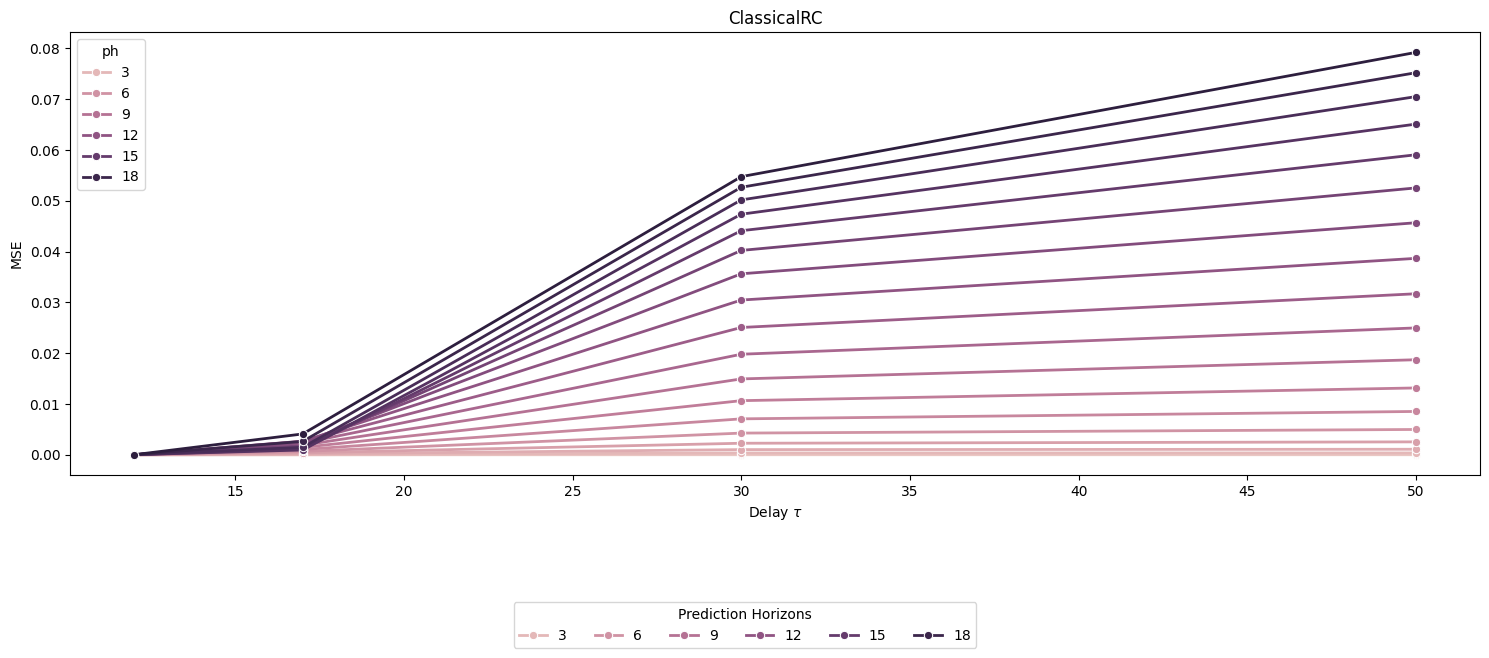

In [15]:
# Create figure with subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 6))

# Plot CPMap
sns.lineplot(
    data=df_plot[df_plot['RC'] == 'Classical'],
    x='tau',
    y='rmse',
    hue='ph',
    hue_order=ph_values,
    marker='o',
    linewidth=2,
    # palette=color_dict,
    ax=ax1,
    legend=True
)
ax1.set_title("ClassicalRC")
ax1.set_xlabel(r"Delay $\tau$")
ax1.set_ylabel("MSE")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, 
           title="Prediction Horizons", 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.1),
           ncol=len(ph_values))  # Horizontal legend

plt.tight_layout()
# plt.legend()
plt.subplots_adjust(bottom=0.2)  # Make room for bottom legend
# plt.savefig("figures/mse_vs_tau_all_RCs_even_ph_fixed.pdf", bbox_inches='tight')
plt.show()

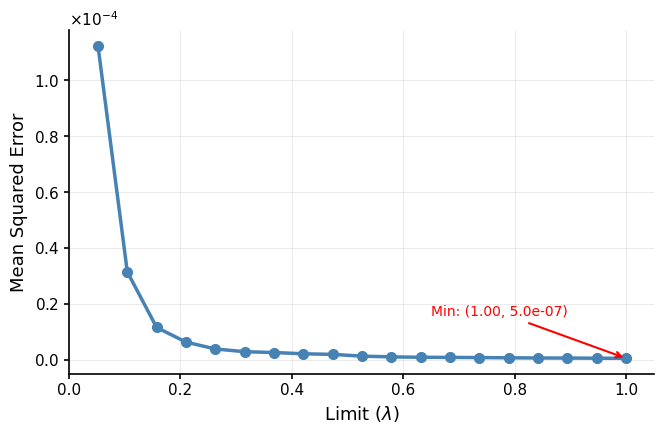

In [19]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":          12,
    "axes.labelsize":     13,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "lines.linewidth":    2.5,
    "lines.markersize":   7,
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.6,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

df = pd.read_csv("mse_limit_17_normalized.csv")

mse_cols = [f"mse_{i}" for i in range(20)]
mse_vals = df[mse_cols].values.flatten()

x_all = np.linspace(0, 1, 20)
x = x_all[1:]       # skip λ=0
y = mse_vals[1:]

min_idx = np.argmin(y)
min_x, min_y = x[min_idx], y[min_idx]

width = 5.5
fig, ax = plt.subplots(figsize=(6.8, 4.5)) #(width, width / 1.618)

ax.plot(x, y, 'o-', color='steelblue')

ax.annotate(
    f"Min: ({min_x:.2f}, {min_y:.1e})",
    xy=(min_x, min_y),
    xytext=(min_x - 0.35, min_y + 0.15e-4),
    fontsize=10, color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
)

ax.set_xlabel(r"Limit ($\lambda$)")
ax.set_ylabel("Mean Squared Error")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.set_xlim(left=0.0, right=1.05)
ax.set_ylim(bottom=-0.05e-4)

plt.tight_layout()
plt.savefig("figures/mse_vs_limit.pdf")
plt.show()


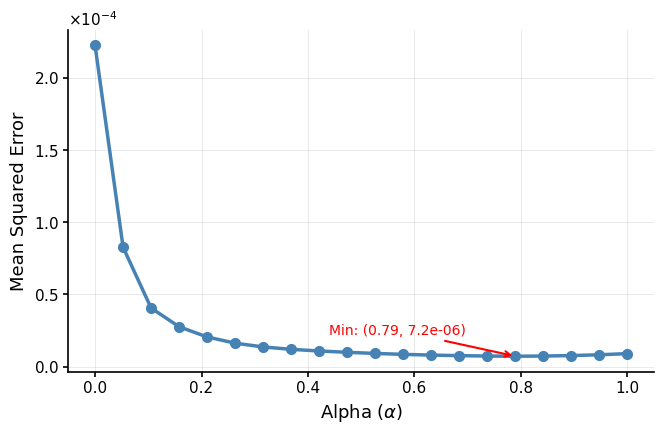

In [30]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":          12,
    "axes.labelsize":     13,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "lines.linewidth":    2.5,
    "lines.markersize":   7,
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.6,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

df = pd.read_csv("mse_alpha_17_normalized.csv")

mse_cols = [f"mse_{i}" for i in range(20)]
mse_vals = df[mse_cols].values.flatten()

x_all = np.linspace(0, 1, 20)
x = x_all[0:]       # skip λ=0
y = mse_vals[0:]

min_idx = np.argmin(y)
min_x, min_y = x[min_idx], y[min_idx]

width = 5.5
fig, ax = plt.subplots(figsize=(6.8, 4.5)) #(width, width / 1.618)

ax.plot(x, y, 'o-', color='steelblue')

ax.annotate(
    f"Min: ({min_x:.2f}, {min_y:.1e})",
    xy=(min_x, min_y),
    xytext=(min_x - 0.35, min_y + 0.15e-4),
    fontsize=10, color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
)

ax.set_xlabel(r"Alpha ($\alpha$)")
ax.set_ylabel("Mean Squared Error")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.set_xlim(left=-0.05, right=1.05)
ax.set_ylim(bottom=-0.035e-4)

plt.tight_layout()
plt.savefig("figures/mse_vs_alpha.pdf")
plt.show()


In [21]:
y

array([8.26717347e-05, 4.06060877e-05, 2.76435970e-05, 2.05837728e-05,
       1.62627955e-05, 1.36495972e-05, 1.20027743e-05, 1.08566601e-05,
       9.94827408e-06, 9.16426409e-06, 8.51593902e-06, 8.01566209e-06,
       7.63091828e-06, 7.35415873e-06, 7.23809507e-06, 7.35137036e-06,
       7.69028599e-06, 8.23195126e-06, 9.04287780e-06])